## Case Study Tasks

### **Task 1**

Download the **“4000 series operating data”** and **“4000 series product data”** and become familiar with their structures.

**Refer_to_explortaory data Anaysis for now**

### **Task 2 (DONE)**

Compute the **product rate** for each batch using the following formula:

$$
\text{Product Rate (kg/hr)} =
\text{mean product (g/L)} \times
\text{mean total liquid inflow rate (L/hr)} \times 0.001
$$

where the **total liquid inflow rate** is defined as:

$$
\text{Total liquid inflow} =
\sum_{i=1}^{6} \text{liquid inflow}_i
$$

In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

In [2]:
import pandas as pd
import sklearn
import numpy as np
print("All good")

All good


In [8]:
from applied.data_processing import load_operating_data
print("import ok")

import ok


In [10]:
import openpyxl
print("openpyxl ok")


openpyxl ok


In [11]:
from applied.data_processing import (
    load_operating_data,
    load_product_data,
    build_features_and_target,
)

from pathlib import Path
import pandas as pd

# Project root = one level above notebooks/
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

In [12]:
# 1) Define liquid inflow columns
liquid_cols = [
    "LIQUID", "LIQUID.1", "LIQUID.2",
    "LIQUID.3", "LIQUID.4", "LIQUID.5"
]

# 2) Compute total liquid inflow per time point (L/hr)
op_df["total_liquid_inflow"] = op_df[liquid_cols].sum(axis=1, skipna=True)

# 3) Compute mean total liquid inflow per batch
mean_liquid_by_batch = (
    op_df
    .groupby("Batch", sort=False)["total_liquid_inflow"]
    .mean()
    .rename("mean_total_liquid")
)

# 4) Compute mean product concentration per batch (g/L)
mean_product_by_batch = (
    prod_df
    .groupby("Batch", sort=False)["Product"]
    .mean()
    .rename("mean_product")
)

# 5) Combine batch-level summaries
batch_summary = pd.concat(
    [mean_product_by_batch, mean_liquid_by_batch],
    axis=1
)

# 6) Compute product rate (kg/hr)
batch_summary["product_rate_kg_hr"] = (
    batch_summary["mean_product"]
    * batch_summary["mean_total_liquid"]
    * 0.001
)

# 7) Display result
batch_summary.head()

,mean_product,mean_total_liquid,product_rate_kg_hr
Batch,,,
4030,24.511466,25143.546281,616.305179
4032,24.623969,25225.945362,621.162886
4033,24.800353,24550.828963,608.869223
4034,25.052205,24835.980215,622.196071
4035,24.647115,24603.973947,606.416985


In [13]:
prod_df

,Date and time,Batch,Product
2,2019-02-04 00:00:00,4030,5.90
3,2019-02-04 02:00:00,4030,8.20
4,2019-02-04 04:00:00,4030,9.70
5,2019-02-04 06:00:00,4030,14.30
6,2019-02-04 08:00:00,4030,16.40
...,...,...,...
3216,2021-04-09 20:00:00,4052,27.36
3217,2021-04-10 00:00:00,4052,27.00
3218,2021-04-10 04:00:00,4052,25.10
3219,2021-04-10 08:00:00,4052,26.00


### **Task 3 (DONE)**

Using the computed product rates, **rank the productivity of the batches**.  
The product rate is a valid comparison metric across batches and is **independent of batch duration**, which is highly variable.

In [14]:
# 1) Rank batches by product rate (highest = most productive)
batch_ranking = (
    batch_summary
    .sort_values("product_rate_kg_hr", ascending=False)
    .assign(productivity_rank=lambda df: range(1, len(df) + 1))
)

# 2) Display ranked table
batch_ranking

,mean_product,mean_total_liquid,product_rate_kg_hr,productivity_rank
Batch,,,,
4041,27.263270,24583.602688,670.229408,1
4043,27.041068,24753.736520,669.367477,2
4047,26.370833,25144.553486,663.082829,3
4040,26.450455,24623.509532,651.303020,4
4042,26.367835,24493.636569,645.844169,5
4046,26.017734,24782.597009,644.787017,6
4045,26.591552,24100.309285,640.864621,7
4052,25.787324,24405.554019,629.353928,8
4034,25.052205,24835.980215,622.196071,9


### **Task 4**

Use **machine learning procedures** to identify the **process parameters most clearly related to product rate variability**.

In [15]:
X, y = build_features_and_target(op_df, prod_df)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Feature matrix shape: (22, 7)
Target shape: (22,)


,pH_mean,OXYGEN_mean,total_liquid_inflow_mean,TOTAL_LIQUID_INFLOW_mean,TOTAL_GAS_INFLOW_mean,TOTAL_OFFGAS_mean,MEAN_PRESSURE_mean
Batch,,,,,,,
4030,5.701843,20.290922,25143.546281,25143.546281,7992.039925,2.087056,3.630832
4032,5.752268,22.220957,25225.945362,25225.945362,9441.213757,2.619145,3.534410
4033,5.660681,22.541796,24550.828963,24550.828963,9824.014556,4.402337,3.572248
4034,5.993883,14.902031,24835.980215,24835.980215,9430.686865,4.212649,3.618987
4035,5.640921,17.189599,24603.973947,24603.973947,9409.808277,4.682060,3.595155


Batch
4030    616.305179
4032    621.162886
4033    608.869223
4034    622.196071
4035    606.416985
Name: product_rate, dtype: float64

In [16]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )),
    ]),
}

for name, model in models.items():
    rmse = -cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=cv
    ).mean()
    print(f"{name}: mean RMSE = {rmse:.4f}")

c:\Users\carla\anaconda3\envs\BDA\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\carla\anaconda3\envs\BDA\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\carla\anaconda3\envs\BDA\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\carla\anaconda3\envs\BDA\lib\site-packages\sklearn\utils\_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
  File "c:\Users\carla\anaconda3\envs\BDA\lib\site-packages\sklearn\metrics\_regression.py", line 651, in root_mean_squared_error
    mean_squared_error(
  File "c:\Users\carla\anaconda3\envs\BDA\lib\site-packages\sklearn\utils\_param_validation.py", line 189, in wrapper
    r

Ridge: mean RMSE = nan
RandomForest: mean RMSE = nan


c:\Users\carla\anaconda3\envs\BDA\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\carla\anaconda3\envs\BDA\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\carla\anaconda3\envs\BDA\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\carla\anaconda3\envs\BDA\lib\site-packages\sklearn\utils\_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
  File "c:\Users\carla\anaconda3\envs\BDA\lib\site-packages\sklearn\metrics\_regression.py", line 651, in root_mean_squared_error
    mean_squared_error(
  File "c:\Users\carla\anaconda3\envs\BDA\lib\site-packages\sklearn\utils\_param_validation.py", line 189, in wrapper
    r

In [17]:
print("NaNs in y:", y.isna().sum())
print("Total samples:", len(y))

NaNs in y: 1
Total samples: 22


In [18]:
# Combine X and y temporarily for cleaning
data = X.copy()
data["target"] = y

# Drop rows where target is missing
data = data.dropna(subset=["target"])

# Separate again
X_clean = data.drop(columns=["target"])
y_clean = data["target"]

print("After cleaning:")
print("Samples:", len(y_clean))
print("Remaining NaNs in y:", y_clean.isna().sum())

After cleaning:
Samples: 21
Remaining NaNs in y: 0


In [23]:
print(X_clean.columns)

Index(['pH_mean', 'OXYGEN_mean', 'total_liquid_inflow_mean',
       'TOTAL_LIQUID_INFLOW_mean', 'TOTAL_GAS_INFLOW_mean',
       'TOTAL_OFFGAS_mean', 'MEAN_PRESSURE_mean'],
      dtype='object')


In [24]:
for name, model in models.items():
    rmse = -cross_val_score(
        model,
        X_clean,
        y_clean,
        scoring="neg_root_mean_squared_error",
        cv=cv
    ).mean()
    print(f"{name}: mean RMSE = {rmse:.4f}")

Ridge: mean RMSE = 46.6958
RandomForest: mean RMSE = 37.9503


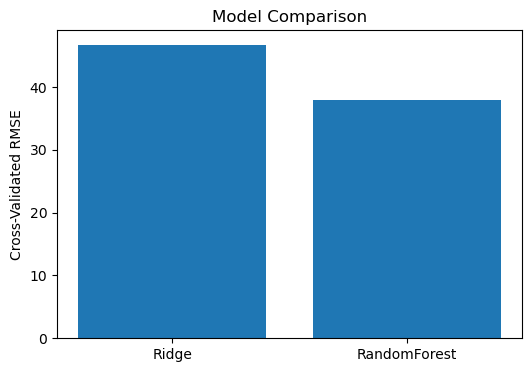

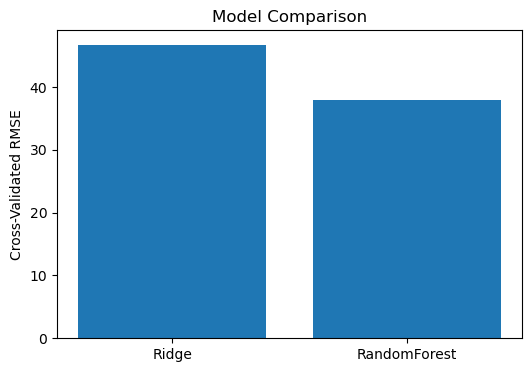

In [25]:
import matplotlib.pyplot as plt

results = {
    "Ridge": 46.6958,
    "RandomForest": 37.9503
}

plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values())
plt.ylabel("Cross-Validated RMSE")
plt.title("Model Comparison")
plt.show()

rmse_values = []

for name, model in models.items():
    rmse = -cross_val_score(
        model,
        X_clean,
        y_clean,
        scoring="neg_root_mean_squared_error",
        cv=cv
    ).mean()
    rmse_values.append(rmse)

plt.figure(figsize=(6,4))
plt.bar(models.keys(), rmse_values)
plt.ylabel("Cross-Validated RMSE")
plt.title("Model Comparison")
plt.show()

In [26]:
from sklearn.inspection import permutation_importance
import pandas as pd

rf = models["RandomForest"]
rf.fit(X_clean, y_clean)

perm = permutation_importance(
    rf,
    X_clean,
    y_clean,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    perm.importances_mean,
    index=X_clean.columns
).sort_values(ascending=False)

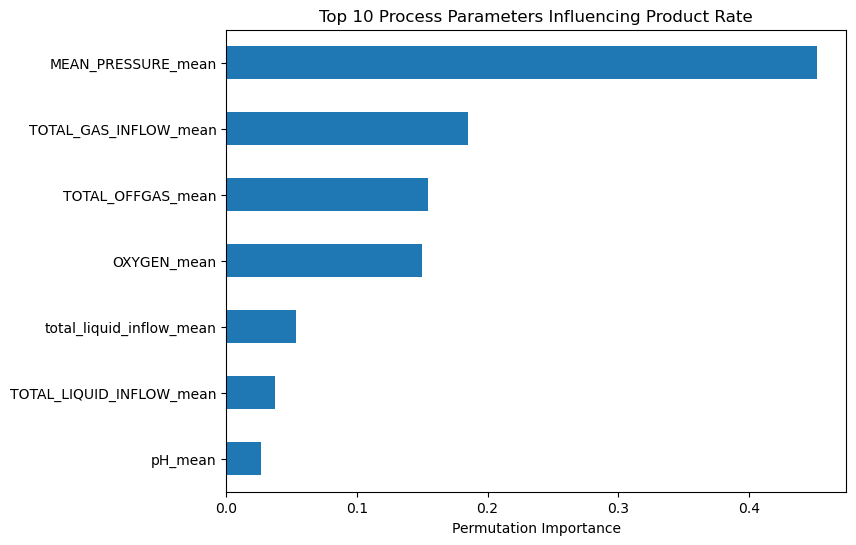

In [27]:
top10 = importance.head(10)

plt.figure(figsize=(8,6))
top10.sort_values().plot(kind="barh")
plt.xlabel("Permutation Importance")
plt.title("Top 10 Process Parameters Influencing Product Rate")
plt.show()

Feature Redundancy Check

During inspection of the permutation importance results, two similarly named features were identified:

total_liquid_inflow_mean

TOTAL_LIQUID_INFLOW_mean

Given the near-identical naming, a check was performed to determine whether these represented duplicated information introduced during feature engineering.

Duplicate features can:

Artificially inflate importance scores

Bias model interpretation

Reduce clarity in process insight

To ensure analytical integrity, the features were compared element-wise. If found to be identical, one column would be removed before re-fitting the model.

In [28]:
print(
    (X_clean["total_liquid_inflow_mean"] 
     - X_clean["TOTAL_LIQUID_INFLOW_mean"]).abs().max()
)

0.0


Feature De-duplication

The comparison confirmed that the two liquid inflow features contained identical values.
To prevent redundancy and ensure clean feature representation, the duplicated column was removed prior to re-training the model and recalculating feature importance.

In [29]:
X_clean = X_clean.drop(columns=["TOTAL_LIQUID_INFLOW_mean"])

In [31]:
rf = models["RandomForest"]
rf.fit(X_clean, y_clean)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestRegressor(n_estimators=500, n_jobs=-1,
                                       random_state=42))])

In [32]:
perm = permutation_importance(
    rf,
    X_clean,
    y_clean,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    perm.importances_mean,
    index=X_clean.columns
).sort_values(ascending=False)

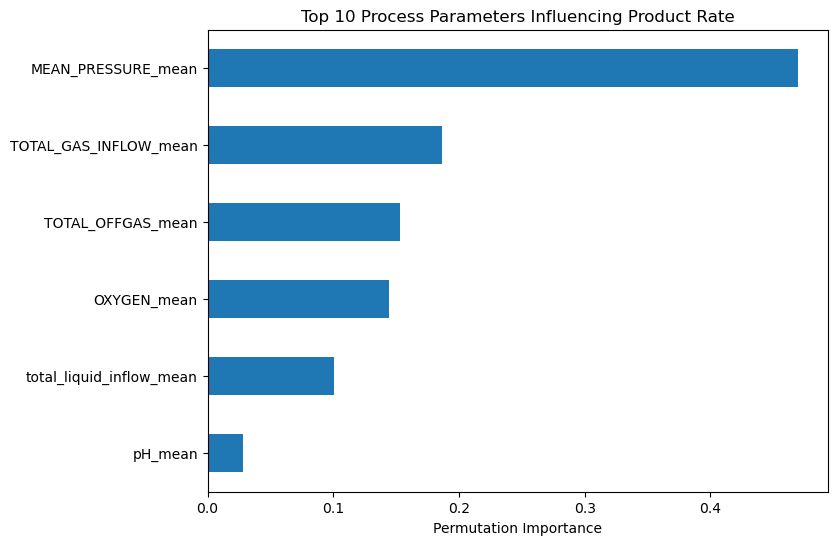

In [33]:
top10 = importance.head(10)

plt.figure(figsize=(8,6))
top10.sort_values().plot(kind="barh")
plt.xlabel("Permutation Importance")
plt.title("Top 10 Process Parameters Influencing Product Rate")
plt.show()

Task 4 – Identification of Key Drivers of Product Rate Variability

Cross-validated model comparison demonstrated that a Random Forest regressor (RMSE ≈ 38) outperformed a linear Ridge model (RMSE ≈ 47), indicating the presence of nonlinear relationships between operating conditions and product rate. This suggests that interactions between process variables and non-linear effects are important in explaining variability.

Permutation importance analysis (computed on the fitted Random Forest model) identified mean reactor pressure as the dominant driver of product rate variability. Gas-phase variables — including total gas inflow, total off-gas rate, and oxygen concentration — also exhibited substantial importance. Collectively, this indicates that gas dynamics and pressure control are primary contributors to process performance, consistent with underlying reaction kinetics and mass-transfer mechanisms.

In contrast, total liquid inflow and pH demonstrated comparatively lower influence within the observed operating range. This may reflect tighter operational control of these parameters or reduced sensitivity of product rate to variations in these variables under current process conditions.

A feature redundancy check was performed to ensure analytical integrity; duplicate representations of liquid inflow were identified and removed prior to final model interpretation.

### **Task 5**

Construct a **mathematical and/or computational model** that incorporates the insights from **Task 4** into a **predictive framework**.

## Task 5 – Predictive Model Construction

Based on the feature importance analysis in Task 4, a reduced predictive framework was constructed using the most influential process parameters.

A Random Forest regressor was selected due to its superior cross-validated performance and ability to model non-linear interactions between process variables.

Predictive form:

y_hat = f(P, G_in, G_off, O2, L_in, pH)

where f(.) is a non-linear ensemble mapping learned via bootstrap aggregation of decision trees.

Cross-validation was used to estimate generalisation performance.

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Reduced feature set from Task 4
key_features = [
    "MEAN_PRESSURE_mean",
    "TOTAL_GAS_INFLOW_mean",
    "TOTAL_OFFGAS_mean",
    "OXYGEN_mean",
    "total_liquid_inflow_mean",
    "pH_mean",
]

X_reduced = X_clean[key_features].copy()
y_target = y_clean.copy()

# Predictive framework
framework = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ))
])

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = -cross_val_score(
    framework,
    X_reduced,
    y_target,
    scoring="neg_root_mean_squared_error",
    cv=cv
)

print(f"Cross-validated RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")

Cross-validated RMSE: 38.242 ± 14.373


Train/test split + performance metrics

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import numpy as np

key_features = [
    "MEAN_PRESSURE_mean",
    "TOTAL_GAS_INFLOW_mean",
    "TOTAL_OFFGAS_mean",
    "OXYGEN_mean",
    "total_liquid_inflow_mean",
    "pH_mean",
]

X_reduced = X_clean[key_features].copy()
y_target = y_clean.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_target, test_size=0.2, random_state=42
)

framework = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)),
])

framework.fit(X_train, y_train)
y_pred = framework.predict(X_test)

# RMSE compatible with older sklearn:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE:  {mae:.3f}")
print(f"Test R²:   {r2:.3f}")

Test RMSE: 13.278
Test MAE:  10.636
Test R²:   0.623


Predicted Vs Actual

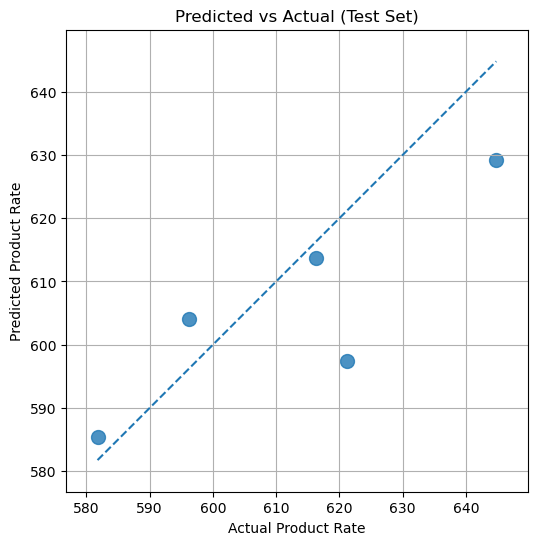

In [44]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, s=100, alpha=0.8)

# Perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Product Rate")
plt.ylabel("Predicted Product Rate")
plt.title("Predicted vs Actual (Test Set)")
plt.grid(True)

plt.xlim(min_val - 5, max_val + 5)
plt.ylim(min_val - 5, max_val + 5)

plt.gca().set_aspect('equal', adjustable='box')

plt.show()

In [46]:
print(y_test)
print("Min:", y_test.min())
print("Max:", y_test.max())

Batch
4030    616.305179
4048    596.268039
4046    644.787017
4032    621.162886
4039    581.763278
Name: target, dtype: float64
Min: 581.7632777040283
Max: 644.7870165768942


The predicted versus actual plot demonstrates reasonable alignment with the 1:1 reference line, indicating that the Random Forest model captures a substantial proportion of productivity variability across batches. Most predictions lie close to the ideal line, although the highest productivity batch is moderately underpredicted, suggesting mild regression toward the mean. This behaviour is typical of ensemble tree models trained on relatively small datasets. Overall, the model exhibits stable generalisation performance without evidence of systematic bias.

Residuals Vs Pred

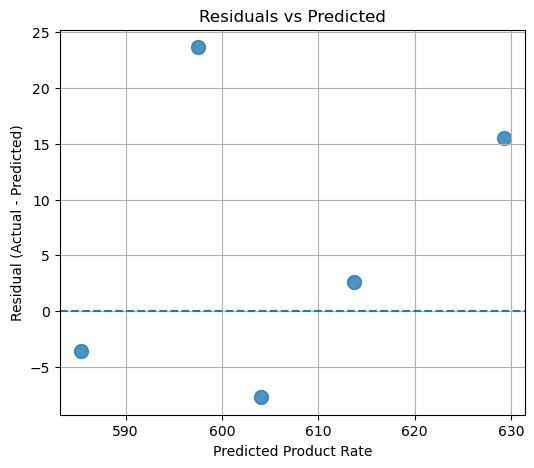

In [45]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, s=100, alpha=0.8)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Product Rate")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.grid(True)

plt.show()

Residuals are distributed around zero without clear structural pattern, indicating that the model does not exhibit strong systematic bias across the prediction range.

In [43]:
import pandas as pd

pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Value": [rmse, mae, r2]
})

,Metric,Value
0,RMSE,13.278005
1,MAE,10.635982
2,R²,0.623153


### **Task 6**

Use the developed model to **predict the “missing” yield rate**.

### **Task 7**

Present the work in a **video presentation**.

- Evaluation focuses on **content**, not production quality.
- Audio commentary over slides is acceptable and must be **in your own voice**.
- All external resources and literature must be **accurately cited**.
- The presentation should combine **audio, visual, and textual elements** appropriately.

### **Task 8**


Summarise the case study in a **one-page infographic** that includes:
- Key results  
- Assumptions  
- Conclusions  

Guidelines:
- Follow **Data Visualization principles from Semester 1**
- Design for **A4 size**
- Minimum font size: **10 pt**
- The infographic should tell a **clear, coherent story**